<a href="https://colab.research.google.com/github/Rameenumer/Weather-Classification-System/blob/main/Weather_Classification_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
✅ All libraries imported!


Loading Snowy: 100%|██████████| 20/20 [00:07<00:00,  2.70it/s]



✅ Total images (with augmentation): 600
✅ Label mapping: {0: 'Sunny', 1: 'Rainy', 2: 'Cloudy', 3: 'Foggy', 4: 'Snowy'}


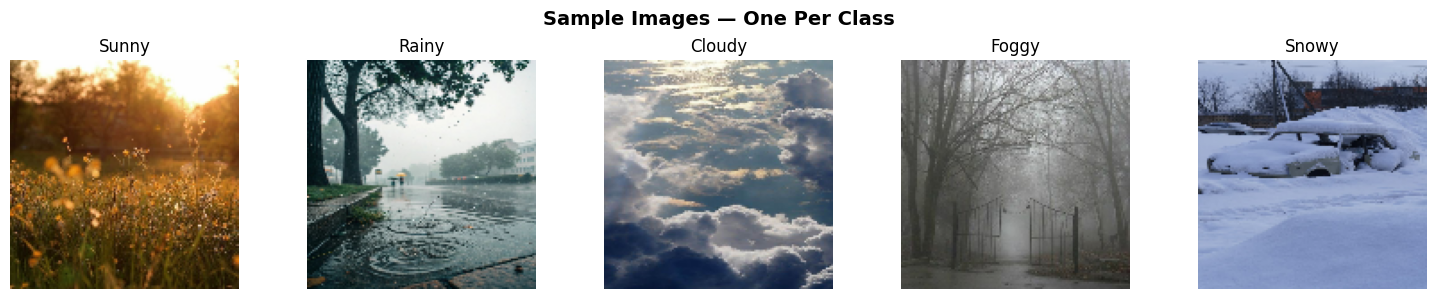

Extracting features: 100%|██████████| 600/600 [03:44<00:00,  2.67it/s]



✅ Feature matrix shape: (600, 8246)


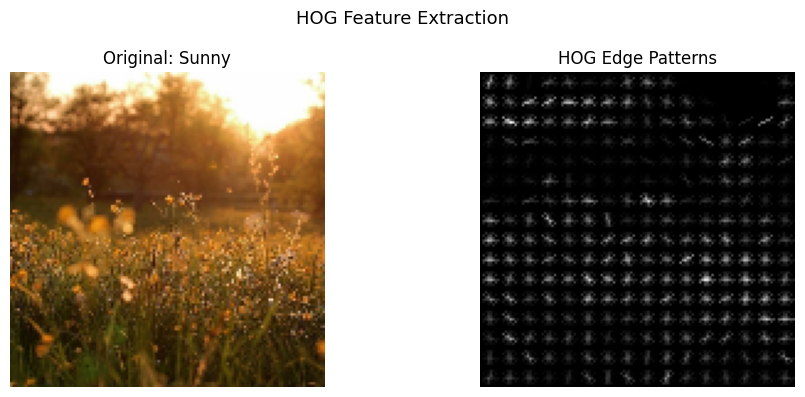

Training samples : 480
Testing  samples : 120
✅ PCA reduced features: 8246 → 294

⏳ Running GridSearchCV for best SVM hyperparameters...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

✅ Best SVM params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
✅ Best CV Accuracy: 85.21%

⏳ Training Ensemble (SVM + RF + GradientBoosting)...
✅ Training complete!

🎯 Test Accuracy : 78.33%

📋 Classification Report:

              precision    recall  f1-score   support

       Sunny       1.00      0.79      0.88        24
       Rainy       0.58      0.75      0.65        24
      Cloudy       0.78      0.88      0.82        24
       Foggy       0.94      0.67      0.78        24
       Snowy       0.77      0.83      0.80        24

    accuracy                           0.78       120
   macro avg       0.81      0.78      0.79       120
weighted avg       0.81      0.78      0.79       120



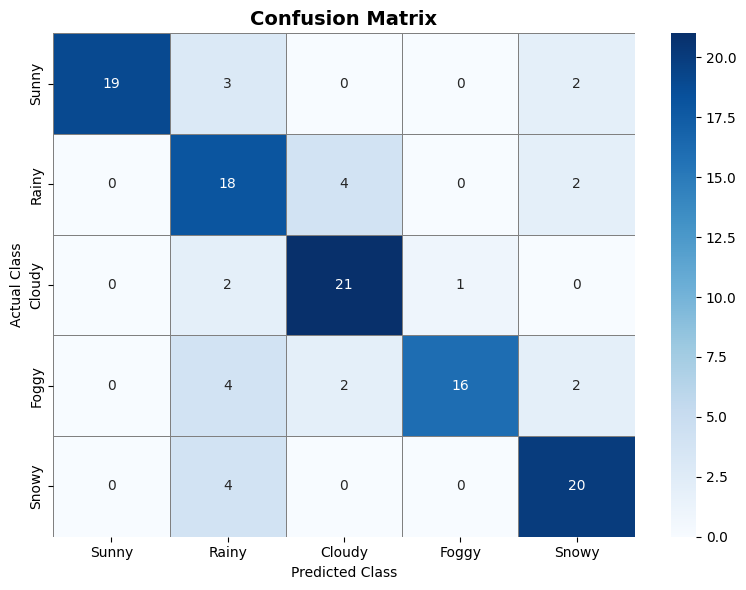

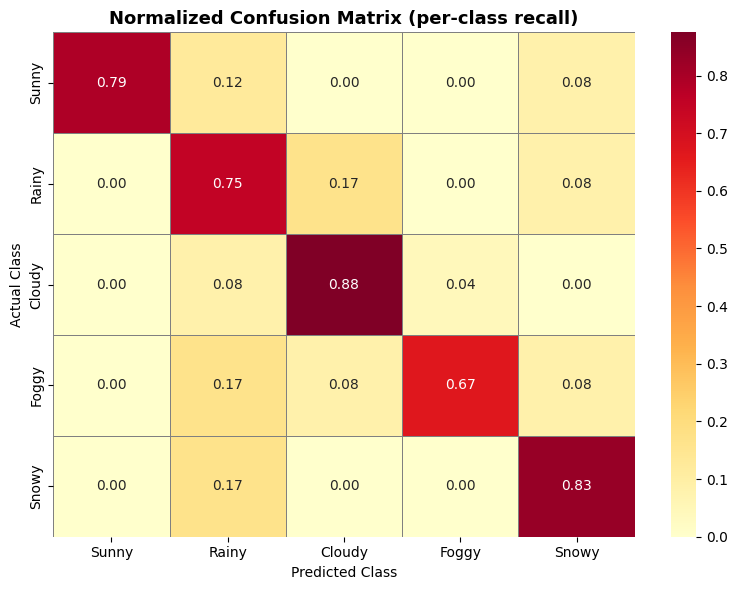

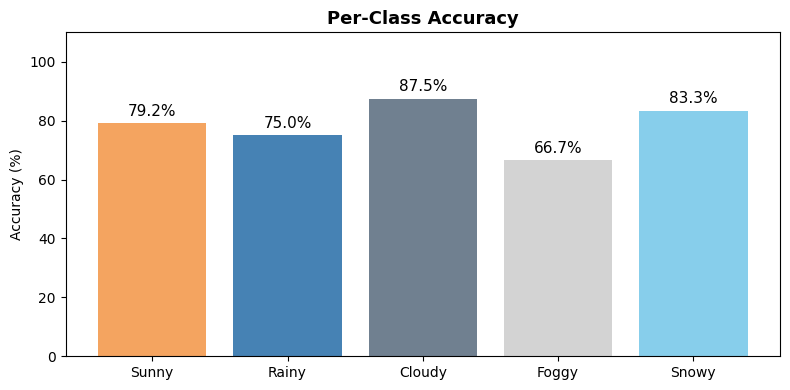


⏳ Running 5-Fold Cross-Validation on full dataset...
📈 Cross-Validation Results (5 Folds):
   Scores  : ['85.0%', '85.0%', '85.0%', '85.0%', '90.0%']
   Average : 86.00%
   Std Dev : ±2.00%


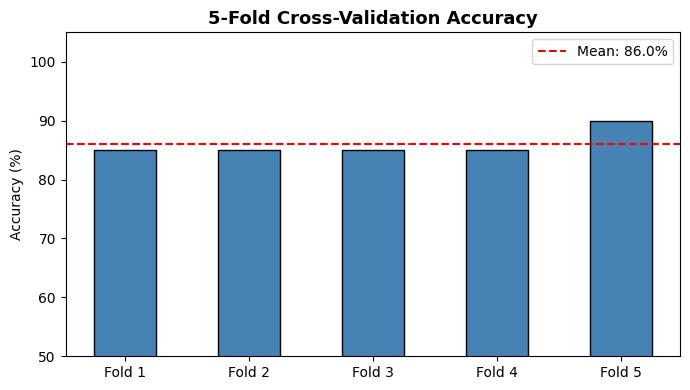

Extracting features: 100%|██████████| 1/1 [00:00<00:00,  2.89it/s]


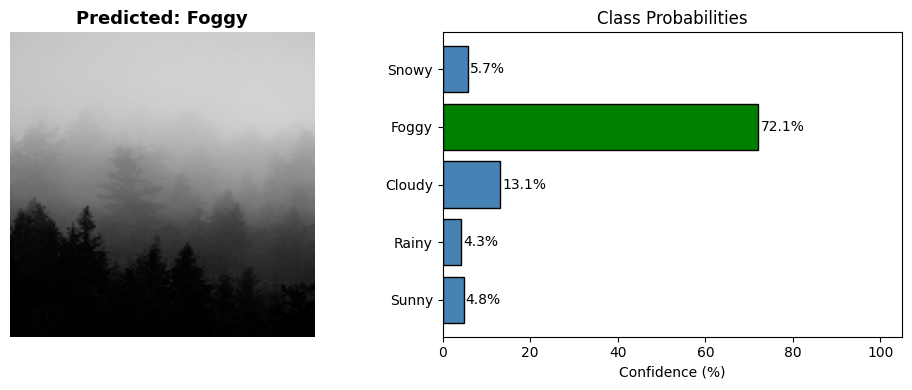


✅ Predicted Class : Foggy
   Confidence      : 72.1%

✅ Ensemble model, scaler & PCA saved to Google Drive!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from skimage.feature import hog, local_binary_pattern
from skimage.filters import gabor

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

# ══════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════
dataset_path = "/content/drive/MyDrive/DATASET"
categories   = ["Sunny", "Rainy", "Cloudy", "Foggy", "Snowy"]
IMG_SIZE     = 128

# ══════════════════════════════════════════════════════════════
# STEP 1: DATA LOADING + AUGMENTATION
# ══════════════════════════════════════════════════════════════
def augment_image(img_bgr):
    """Returns list of augmented BGR images from one original."""
    augmented = [img_bgr]

    # Horizontal flip
    augmented.append(cv2.flip(img_bgr, 1))

    # Brightness up / down
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    for factor in [0.75, 1.25]:
        bright = hsv.copy()
        bright[:, :, 2] = np.clip(bright[:, :, 2] * factor, 0, 255)
        augmented.append(cv2.cvtColor(bright.astype(np.uint8), cv2.COLOR_HSV2BGR))

    # Slight rotation (±10°)
    h, w = img_bgr.shape[:2]
    for angle in [-10, 10]:
        M   = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
        rot = cv2.warpAffine(img_bgr, M, (w, h))
        augmented.append(rot)

    return augmented   # 5 images per original

raw_images_bgr = []
labels         = []

for label_index, category in enumerate(categories):
    folder_path = os.path.join(dataset_path, category)
    files       = os.listdir(folder_path)

    for img_name in tqdm(files, desc=f"Loading {category}"):
        try:
            img_path = os.path.join(folder_path, img_name)
            img_bgr  = cv2.imread(img_path)
            if img_bgr is None:
                continue
            img_bgr  = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE))

            for aug_img in augment_image(img_bgr):
                raw_images_bgr.append(aug_img)
                labels.append(label_index)

        except Exception as e:
            print(f"  Skipped {img_name}: {e}")

raw_images_bgr = np.array(raw_images_bgr)
labels         = np.array(labels)

print(f"\n✅ Total images (with augmentation): {len(raw_images_bgr)}")
print(f"✅ Label mapping: {dict(enumerate(categories))}")

# ══════════════════════════════════════════════════════════════
# STEP 2: VISUALISE ONE SAMPLE PER CLASS
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle("Sample Images — One Per Class", fontsize=14, fontweight='bold')
for i, category in enumerate(categories):
    idx = np.where(labels == i)[0][0]
    axes[i].imshow(cv2.cvtColor(raw_images_bgr[idx], cv2.COLOR_BGR2RGB))
    axes[i].set_title(category)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════
# STEP 3: MULTI-FEATURE EXTRACTION
#   HOG  → edge/gradient patterns
#   LBP  → texture information
#   HSV histograms → color distribution (sky color, snow brightness)
#   Gabor → frequency + orientation texture
# ══════════════════════════════════════════════════════════════
def extract_hog(gray):
    return hog(gray, orientations=9, pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), visualize=False, feature_vector=True)

def extract_lbp(gray):
    lbp = local_binary_pattern(gray, P=24, R=3, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=26, range=(0, 26), density=True)
    return hist

def extract_color_hist(img_bgr):
    """HSV channel histograms — captures sky color, snow whiteness, etc."""
    hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    feat = []
    bins = [32, 32, 32]
    for ch, b in zip(range(3), bins):
        hist, _ = np.histogram(hsv[:, :, ch], bins=b,
                               range=(0, 256), density=True)
        feat.extend(hist)
    return np.array(feat)

def extract_gabor_features(gray):
    """Gabor filter responses — frequency-based texture."""
    feat = []
    for frequency in [0.1, 0.25, 0.4]:
        for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
            filt_real, _ = gabor(gray, frequency=frequency, theta=theta)
            feat.append(filt_real.mean())
            feat.append(filt_real.var())
    return np.array(feat)

def extract_all_features(images_bgr):
    feature_list = []
    for img_bgr in tqdm(images_bgr, desc="Extracting features"):
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float64) / 255.0

        hog_feat   = extract_hog(gray)
        lbp_feat   = extract_lbp(gray)
        color_feat = extract_color_hist(img_bgr)
        gabor_feat = extract_gabor_features(gray)

        combined = np.concatenate([hog_feat, lbp_feat, color_feat, gabor_feat])
        feature_list.append(combined)
    return np.array(feature_list)

X = extract_all_features(raw_images_bgr)
y = labels
print(f"\n✅ Feature matrix shape: {X.shape}")

# ══════════════════════════════════════════════════════════════
# STEP 4: HOG VISUALISATION (for report)
# ══════════════════════════════════════════════════════════════
sample_gray = cv2.cvtColor(raw_images_bgr[0], cv2.COLOR_BGR2GRAY).astype(np.float64) / 255.0
_, hog_img  = hog(sample_gray, orientations=9, pixels_per_cell=(8, 8),
                  cells_per_block=(2, 2), visualize=True, feature_vector=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(cv2.cvtColor(raw_images_bgr[0], cv2.COLOR_BGR2RGB))
ax1.set_title(f'Original: {categories[labels[0]]}')
ax1.axis('off')
ax2.imshow(hog_img, cmap='gray')
ax2.set_title('HOG Edge Patterns')
ax2.axis('off')
plt.suptitle('HOG Feature Extraction', fontsize=13)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════
# STEP 5: TRAIN / TEST SPLIT  (stratified)
# ══════════════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

# ══════════════════════════════════════════════════════════════
# STEP 6: SCALING + PCA
# ══════════════════════════════════════════════════════════════
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# PCA — keep 95% variance, reduces noise & speeds up training
pca            = PCA(n_components=0.95, random_state=42)
X_train_pca    = pca.fit_transform(X_train_scaled)
X_test_pca     = pca.transform(X_test_scaled)

print(f"✅ PCA reduced features: {X_train_scaled.shape[1]} → {X_train_pca.shape[1]}")

# ══════════════════════════════════════════════════════════════
# STEP 7: HYPERPARAMETER TUNING  (GridSearchCV on SVM)
# ══════════════════════════════════════════════════════════════
print("\n⏳ Running GridSearchCV for best SVM hyperparameters...")
param_grid = {
    'C'    : [1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf', 'poly']
}
grid_search = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_pca, y_train)

best_params = grid_search.best_params_
print(f"\n✅ Best SVM params: {best_params}")
print(f"✅ Best CV Accuracy: {grid_search.best_score_*100:.2f}%")

# ══════════════════════════════════════════════════════════════
# STEP 8: ENSEMBLE MODEL (SVM + Random Forest + Gradient Boosting)
# ══════════════════════════════════════════════════════════════
svm_best = SVC(**best_params, random_state=42, probability=True)
rf       = RandomForestClassifier(n_estimators=300, max_depth=20,
                                   min_samples_split=4, random_state=42, n_jobs=-1)
gb       = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                       max_depth=5, random_state=42)

ensemble = VotingClassifier(
    estimators=[('svm', svm_best), ('rf', rf), ('gb', gb)],
    voting='soft'
)

print("\n⏳ Training Ensemble (SVM + RF + GradientBoosting)...")
ensemble.fit(X_train_pca, y_train)
print("✅ Training complete!")

# ══════════════════════════════════════════════════════════════
# STEP 9: EVALUATION METRICS
# ══════════════════════════════════════════════════════════════
y_pred   = ensemble.predict(X_test_pca)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Test Accuracy : {accuracy * 100:.2f}%")

# --- Classification Report ---
print("\n📋 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=categories))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories,
            linewidths=0.5, linecolor='gray')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

# --- Normalized Confusion Matrix ---
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=categories, yticklabels=categories,
            linewidths=0.5, linecolor='gray')
plt.title('Normalized Confusion Matrix (per-class recall)', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

# --- Per-class accuracy bar chart ---
per_class_acc = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(8, 4))
bars = plt.bar(categories, per_class_acc * 100,
               color=['#F4A460','#4682B4','#708090','#D3D3D3','#87CEEB'])
plt.ylim(0, 110)
plt.ylabel("Accuracy (%)")
plt.title("Per-Class Accuracy", fontsize=13, fontweight='bold')
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5, f"{acc*100:.1f}%",
             ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════
# STEP 10: 5-FOLD CROSS VALIDATION
# ══════════════════════════════════════════════════════════════
print("\n⏳ Running 5-Fold Cross-Validation on full dataset...")
X_all_scaled = scaler.fit_transform(X)
X_all_pca    = pca.transform(scaler.transform(X))   # use fitted scaler/pca

skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_model = SVC(**best_params, random_state=42)
cv_scores = cross_val_score(cv_model, X_all_pca, y, cv=skf, scoring='accuracy', n_jobs=-1)

print("📈 Cross-Validation Results (5 Folds):")
print(f"   Scores  : {[f'{s*100:.1f}%' for s in cv_scores]}")
print(f"   Average : {cv_scores.mean()*100:.2f}%")
print(f"   Std Dev : ±{cv_scores.std()*100:.2f}%")

# CV bar plot
plt.figure(figsize=(7, 4))
plt.bar([f"Fold {i+1}" for i in range(5)], cv_scores * 100,
        color='steelblue', edgecolor='black', width=0.5)
plt.axhline(cv_scores.mean()*100, color='red', linestyle='--',
            label=f'Mean: {cv_scores.mean()*100:.1f}%')
plt.ylim(50, 105)
plt.ylabel("Accuracy (%)")
plt.title("5-Fold Cross-Validation Accuracy", fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════
# STEP 11: PREDICT ON SINGLE IMAGE
# ══════════════════════════════════════════════════════════════
def predict_weather(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print("❌ Image not found. Check the path!")
        return

    img_bgr_resized = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE))
    features        = extract_all_features([img_bgr_resized])   # returns (1, N)
    features_scaled = scaler.transform(features)
    features_pca    = pca.transform(features_scaled)

    proba           = ensemble.predict_proba(features_pca)[0]
    pred_idx        = np.argmax(proba)
    predicted_class = categories[pred_idx]

    # Plot image + confidence bars
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(cv2.cvtColor(img_bgr_resized, cv2.COLOR_BGR2RGB))
    ax1.set_title(f"Predicted: {predicted_class}", fontsize=13, fontweight='bold')
    ax1.axis('off')

    colors = ['green' if i == pred_idx else 'steelblue' for i in range(len(categories))]
    ax2.barh(categories, proba * 100, color=colors, edgecolor='black')
    ax2.set_xlabel("Confidence (%)")
    ax2.set_title("Class Probabilities", fontsize=12)
    ax2.set_xlim(0, 105)
    for i, p in enumerate(proba):
        ax2.text(p * 100 + 0.5, i, f"{p*100:.1f}%", va='center', fontsize=10)

    plt.tight_layout()
    plt.show()
    print(f"\n✅ Predicted Class : {predicted_class}")
    print(f"   Confidence      : {proba[pred_idx]*100:.1f}%")
    return predicted_class


test_image_path = "/content/drive/MyDrive/iamge2.jpeg"
predict_weather(test_image_path)

# ══════════════════════════════════════════════════════════════
# STEP 12: SAVE MODELS
# ══════════════════════════════════════════════════════════════
joblib.dump(ensemble, "/content/drive/MyDrive/weather_ensemble_model.pkl")
joblib.dump(scaler,   "/content/drive/MyDrive/weather_scaler.pkl")
joblib.dump(pca,      "/content/drive/MyDrive/weather_pca.pkl")
print("\n✅ Ensemble model, scaler & PCA saved to Google Drive!")
